Line of inquiry 1
* For Q1-2026, what the avg hrs per trip for C300 and P300 What are the top clusters they flew in?
* For last 3 years, what the avg hrs per trip for C300 and Citation Is the trend changing in last 3 years? Is it going up/down or same.

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import fsspec
from zipfile import ZipFile
from io import BytesIO

import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

import warnings
warnings.filterwarnings('ignore')

In [56]:
df_q1 = pd.read_csv(
    'gs://agntworks-data-dev/wheelsup/raw/wingx/WingX_2026.zip',
    usecols=['FlightDate_utc', 'Operator', 'Hours', 'aircraft_model'],
)

print(f'Loaded {len(df_q1):,} rows')
df_q1.head(3)

Loaded 885,823 rows


,FlightDate_utc,Operator,Hours,aircraft_model
0,2026-03-31T07:44:00.000Z,ProAir Aviation GmbH,1.600000,Citation CJ4 Gen2
1,2026-03-31T20:45:00.000Z,CMH Services Aviation Inc,1.266667,Praetor 600
2,2026-03-31T14:27:52.000Z,Deer Jet,1.414444,G550


In [57]:
# Filter to C300 and P300 aircraft — using str.contains
mask_c300 = df_q1['aircraft_model'].str.contains('Challenger 300|Challenger 350|Challenger 3500', na=False)
mask_p300 = df_q1['aircraft_model'].str.contains('Phenom 300', na=False)

df_q1 = df_q1[mask_c300 | mask_p300].copy()

# Label aircraft group
df_q1['aircraft_group'] = np.where(mask_c300[df_q1.index], 'C300', 'P300')

# Label operator group — all Wheels Up entities
df_q1['operator_group'] = np.where(
    df_q1['Operator'].str.contains('Wheels Up', na=False), 'Wheels Up', 'Market'
)

# Clean hours
df_q1['Hours'] = pd.to_numeric(df_q1['Hours'], errors='coerce')
df_q1 = df_q1[df_q1['Hours'] > 0].dropna(subset=['Hours'])

print(f'Filtered to {len(df_q1):,} C300/P300 trips')
df_q1.groupby(['aircraft_group', 'operator_group'])['Hours'].count().to_frame('trips')

Filtered to 134,426 C300/P300 trips


trips
aircraft_group operator_group       
C300           Market          62807
               Wheels Up         719
P300           Market          68665
               Wheels Up        2235

In [58]:
# Q1-2026 Stats Table — mean, std, median, quartiles
stats_q1 = (
    df_q1.groupby(['aircraft_group', 'operator_group'])['Hours']
    .agg(Trips='count', Mean='mean', Std='std', Median='median',
         P25=lambda x: x.quantile(0.25), P75=lambda x: x.quantile(0.75))
    .round(2)
    .reset_index()
)

print('Q1-2026: Avg Hours per Trip — C300 vs P300 (Wheels Up vs Market)')
display(stats_q1)

Q1-2026: Avg Hours per Trip — C300 vs P300 (Wheels Up vs Market)


,aircraft_group,operator_group,Trips,Mean,Std,Median,P25,P75
0,C300,Market,62807,1.82,1.25,1.52,0.83,2.48
1,C300,Wheels Up,719,2.18,1.33,2.02,1.07,3.17
2,P300,Market,68665,1.38,0.83,1.17,0.73,1.90
3,P300,Wheels Up,2235,1.56,0.81,1.47,0.92,2.10


In [59]:
# Top 5 aircraft models by flight count
top5_models_q1 = (
    df_q1['aircraft_model'].value_counts()
    .head(5)
    .index.tolist()
)
df_q1_top5 = df_q1[df_q1['aircraft_model'].isin(top5_models_q1)]

model_order_q1 = (
    df_q1_top5.groupby('aircraft_model')['Hours'].median()
    .sort_values().index.tolist()
)

print('Top 5 models:', top5_models_q1)

Top 5 models: ['Phenom 300', 'Challenger 350', 'Challenger 300', 'Phenom 300-E', 'Challenger 3500']


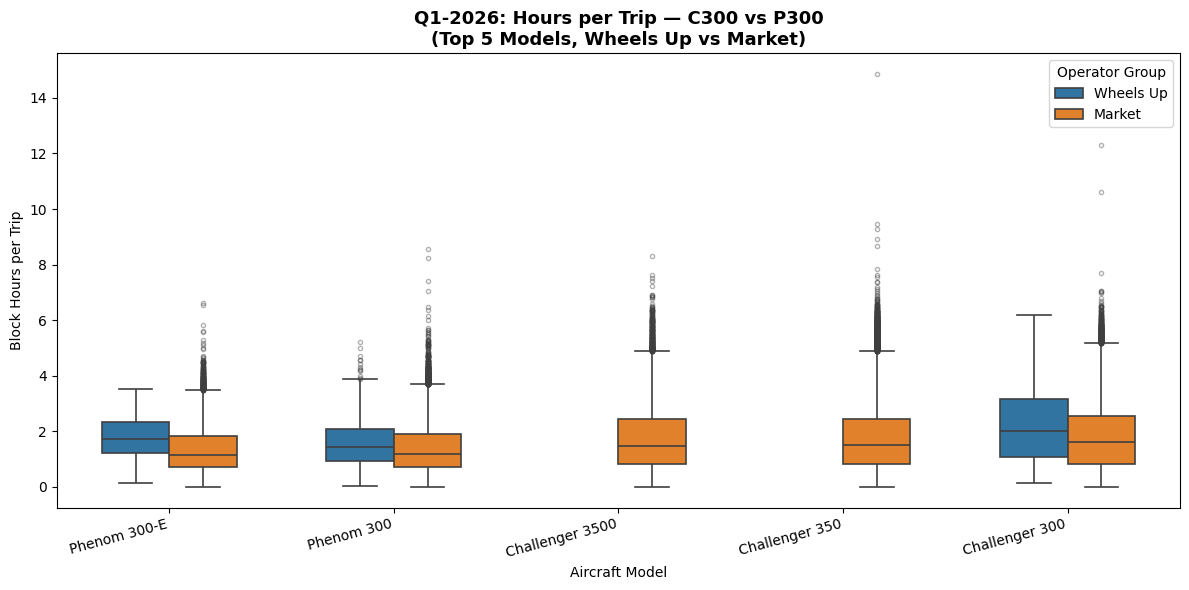

In [60]:
# Q1-2026 Box Plot — C300 vs P300, Wheels Up vs Market
fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(
    data=df_q1_top5,
    x='aircraft_model', y='Hours',
    hue='operator_group',
    order=model_order_q1,
    hue_order=['Wheels Up', 'Market'],
    width=0.6, linewidth=1.2,
    flierprops=dict(marker='o', markersize=3, alpha=0.4),
    ax=ax
)

ax.set_title('Q1-2026: Hours per Trip — C300 vs P300\n(Top 5 Models, Wheels Up vs Market)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Aircraft Model')
ax.set_ylabel('Block Hours per Trip')
ax.legend(title='Operator Group')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

In [61]:
# Q1-2026 Cluster Analysis — load processed corridor file
corr_2026 = pd.read_csv('gs://agntworks-data-dev/wheelsup/processed/wingx/wingx_corridor_2026.csv')

# Filter to C300 + P300 aircraft only
mask_c300_c = corr_2026['aircraft_model'].str.contains('Challenger 300|Challenger 350|Challenger 3500', na=False)
mask_p300_c = corr_2026['aircraft_model'].str.contains('Phenom 300', na=False)
corr_q1 = corr_2026[mask_c300_c | mask_p300_c].copy()

corr_q1['aircraft_group'] = np.where(mask_c300_c[corr_q1.index], 'C300', 'P300')
corr_q1['is_wu']          = corr_q1['Operator'].str.contains('Wheels Up', na=False)

# Split corridor → from/to cluster, stack as endpoints
corr_q1[['from_cluster', 'to_cluster']] = corr_q1['corridor'].str.split('→', expand=True)
from_side  = corr_q1[['aircraft_group', 'is_wu', 'from_cluster', 'flights']].rename(columns={'from_cluster': 'cluster'})
to_side    = corr_q1[['aircraft_group', 'is_wu', 'to_cluster',   'flights']].rename(columns={'to_cluster':   'cluster'})
endpoint_df = pd.concat([from_side, to_side], ignore_index=True)
endpoint_df['cluster'] = endpoint_df['cluster'].str.replace('_CLUSTER', '', regex=False).str.strip()

# Total and WU flights per aircraft_group × cluster
total_by_cluster = endpoint_df.groupby(['aircraft_group', 'cluster'])['flights'].sum().rename('total_flights')
wu_by_cluster    = endpoint_df[endpoint_df['is_wu']].groupby(['aircraft_group', 'cluster'])['flights'].sum().rename('wu_flights')

cluster_share = pd.concat([total_by_cluster, wu_by_cluster], axis=1).fillna(0).reset_index()
cluster_share['wu_share_pct'] = (cluster_share['wu_flights'] / cluster_share['total_flights'] * 100).round(1)

# Top 5 clusters by total market volume per aircraft group
top5_c300 = cluster_share[cluster_share['aircraft_group'] == 'C300'].nlargest(5, 'total_flights')
top5_p300 = cluster_share[cluster_share['aircraft_group'] == 'P300'].nlargest(5, 'total_flights')

print('Top 5 Clusters — C300 (Q1-2026, by total market volume):')
display(top5_c300[['cluster', 'total_flights', 'wu_flights', 'wu_share_pct']])
print('\nTop 5 Clusters — P300 (Q1-2026, by total market volume):')
display(top5_p300[['cluster', 'total_flights', 'wu_flights', 'wu_share_pct']])

Top 5 Clusters — C300 (Q1-2026, by total market volume):


,cluster,total_flights,wu_flights,wu_share_pct
19,MIAMI,9495,146.0,1.5
22,NEW_YORK,7785,113.0,1.5
6,CHICAGO,6387,91.0,1.4
1,ATLANTA,5470,104.0,1.9
34,WASHINGTON_DC,4992,71.0,1.4



Top 5 Clusters — P300 (Q1-2026, by total market volume):


,cluster,total_flights,wu_flights,wu_share_pct
36,ATLANTA,8817,536.0,6.1
52,MIAMI,8561,441.0,5.2
56,ORLANDO,5952,297.0,5.0
42,CHICAGO,5856,313.0,5.3
66,WASHINGTON_DC,5336,266.0,5.0


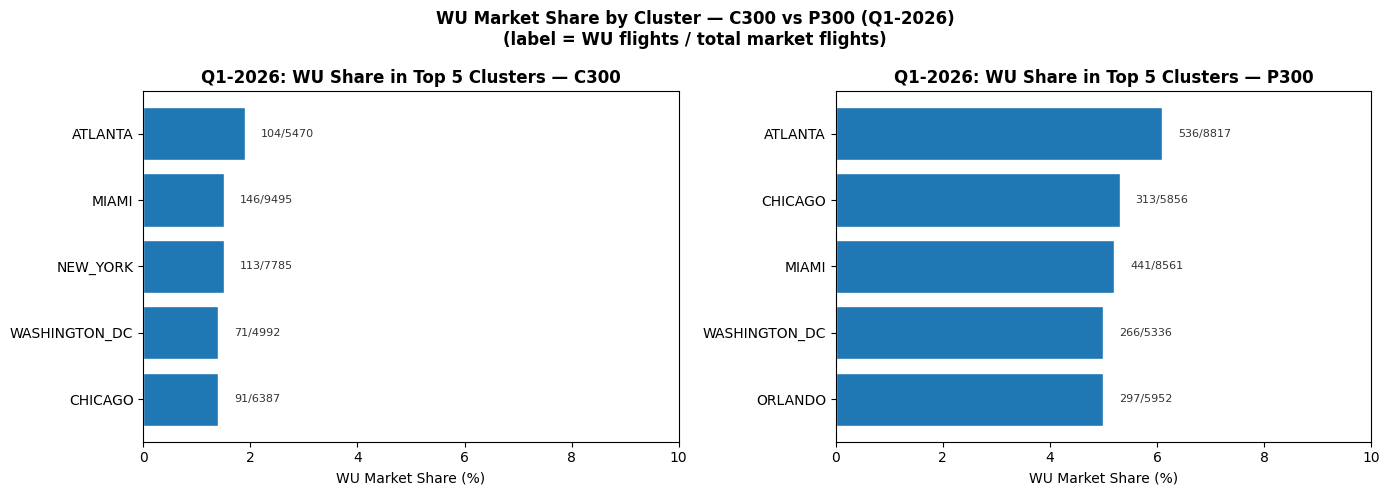

In [62]:
# Q1-2026 Cluster Bar Chart — WU market share % in top 5 clusters
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (grp, top5) in zip(axes, [('C300', top5_c300), ('P300', top5_p300)]):
    top5 = top5.sort_values('wu_share_pct', ascending=True)

    bars = ax.barh(top5['cluster'], top5['wu_share_pct'], edgecolor='white')

    # Annotate: WU flights / total flights
    for bar, (_, row) in zip(bars, top5.iterrows()):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                f"{int(row['wu_flights'])}/{int(row['total_flights'])}",
                va='center', fontsize=8, color='#333333')

    ax.set_xlabel('WU Market Share (%)')
    ax.set_title(f'Q1-2026: WU Share in Top 5 Clusters — {grp}', fontsize=12, fontweight='bold')
    ax.set_xlim(0, max(top5['wu_share_pct'].max() * 1.3, 10))

plt.suptitle('WU Market Share by Cluster — C300 vs P300 (Q1-2026)\n(label = WU flights / total market flights)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# p2

In [63]:
def load_specific_csv_from_zip(url, filename):
    """Load one specific CSV from multi-file ZIP"""
    with fsspec.open(url, 'rb') as f:
        with ZipFile(BytesIO(f.read())) as z:
            return pd.read_csv(z.open(filename))

# url_2026 = "gs://agntworks-data-dev/wheelsup/raw/wingx/WingX_2026.zip"
url_2025 = "gs://agntworks-data-dev/wheelsup/raw/wingx/WingX_2025.zip"
url_2024 = "gs://agntworks-data-dev/wheelsup/raw/wingx/WingX_2024.zip"
url_2023 = "gs://agntworks-data-dev/wheelsup/raw/wingx/WingX_2023.zip"

#  quarter-wise DataFrames (exactly matching your file names)
# 2026
quarters = [
    # (url_2026, 'WINGX_Jan26-Mar26.csv'),
    (url_2025, 'WINGX_Jan25-Mar25.csv'),
    (url_2025, 'WINGX_Apr25-Jun25.csv'),
    (url_2025, 'WINGX_Jul25-Sep25.csv'),
    (url_2025, 'WINGX_Oct25-Dec25.csv'),
    (url_2024, 'WINGX_Jan24-Mar24.csv'),
    (url_2024, 'WINGX_Apr24-Jun24.csv'),
    (url_2024, 'WINGX_Jul24-Sep24.csv'),
    (url_2024, 'WINGX_Oct24-Dec24.csv'),
    (url_2023, 'WINGX_Jan23-Mar23.csv'),
    (url_2023, 'WINGX_Apr23-Jun23.csv'),
    (url_2023, 'WINGX_Jul23-Sep23.csv'),
    (url_2023, 'WINGX_Oct23-Dec23.csv'),
]


In [64]:
# filter early, only what we need
frames = []
COLS = ['FlightDate_utc', 'Operator', 'Hours', 'aircraft_model']
for url, filename in quarters:
    with fsspec.open(url, 'rb') as f:
        with ZipFile(BytesIO(f.read())) as z:
            raw = pd.read_csv(z.open(filename), usecols=COLS, low_memory=False)
    mask_c300 = raw['aircraft_model'].str.contains('Challenger 300|Challenger 350|Challenger 3500', na=False)
    mask_cit  = raw['aircraft_model'].str.contains('Citation', na=False)
    raw = raw[mask_c300 | mask_cit].copy()
    raw['aircraft_group'] = np.where(mask_c300[raw.index], 'C300', 'Citation')
    frames.append(raw)
    print(f'{filename}: {len(raw):,} rows matched')

WINGX_Jan25-Mar25.csv: 329,677 rows matched
WINGX_Apr25-Jun25.csv: 355,801 rows matched
WINGX_Jul25-Sep25.csv: 370,204 rows matched
WINGX_Oct25-Dec25.csv: 360,187 rows matched
WINGX_Jan24-Mar24.csv: 316,240 rows matched
WINGX_Apr24-Jun24.csv: 340,213 rows matched
WINGX_Jul24-Sep24.csv: 352,927 rows matched
WINGX_Oct24-Dec24.csv: 352,016 rows matched
WINGX_Jan23-Mar23.csv: 317,794 rows matched
WINGX_Apr23-Jun23.csv: 341,906 rows matched
WINGX_Jul23-Sep23.csv: 358,343 rows matched
WINGX_Oct23-Dec23.csv: 338,576 rows matched


In [72]:
df_3yr = pd.concat(frames, ignore_index=True)

# All Wheels Up entities
df_3yr['operator_group'] = np.where(
    df_3yr['Operator'].str.contains('Wheels Up', na=False), 'Wheels Up', 'Market'
)
df_3yr['Hours'] = pd.to_numeric(df_3yr['Hours'], errors='coerce')
df_3yr['FlightDate_utc'] = pd.to_datetime(df_3yr['FlightDate_utc'], utc=True, errors='coerce')
df_3yr['year'] = df_3yr['FlightDate_utc'].dt.year
df_3yr = df_3yr[df_3yr['year'].isin([2023, 2024, 2025])]

df_3yr = df_3yr[df_3yr['Hours'] > 0].dropna(subset=['Hours', 'year'])

print(f'\nTotal 3-year trips: {len(df_3yr):,}')
df_3yr.groupby(['year', 'aircraft_group', 'operator_group'])['Hours'].count().to_frame('trips')



Total 3-year trips: 4,131,349


trips
year aircraft_group operator_group         
2023 C300           Market           225179
                    Wheels Up           408
     Citation       Market          1120242
                    Wheels Up          9850
2024 C300           Market           235430
     Citation       Market          1112753
                    Wheels Up         12326
2025 C300           Market           252758
                    Wheels Up          1204
     Citation       Market          1145582
                    Wheels Up         15617

In [73]:
# 3-Year Stats Table
stats_3yr = (
    df_3yr.groupby(['year', 'aircraft_group', 'operator_group'])['Hours']
    .agg(Trips='count', Mean='mean', Std='std', Median='median',
         P25=lambda x: x.quantile(0.25), P75=lambda x: x.quantile(0.75))
    .round(2)
    .reset_index()
)

print('3-Year Avg Hours per Trip — C300 vs Citation (Wheels Up vs Market)')
display(
    stats_3yr.sort_values(['aircraft_group', 'operator_group', 'year'])
    .reset_index(drop=True)
    .style.format({'Mean': '{:.2f}', 'Std': '{:.2f}', 'Median': '{:.2f}',
                   'P25': '{:.2f}', 'P75': '{:.2f}', 'Trips': '{:,.0f}'})
    .background_gradient(subset=['Mean', 'Std'], cmap='Blues')
)

3-Year Avg Hours per Trip — C300 vs Citation (Wheels Up vs Market)


,year,aircraft_group,operator_group,Trips,Mean,Std,Median,P25,P75
0,2023,C300,Market,"225,179",1.71,1.21,1.38,0.80,2.32
1,2024,C300,Market,"235,430",1.71,1.20,1.38,0.80,2.32
2,2025,C300,Market,"252,758",1.70,1.20,1.38,0.80,2.32
3,2023,C300,Wheels Up,408,1.65,1.10,1.37,0.78,2.15
4,2025,C300,Wheels Up,"1,204",2.31,1.40,2.13,1.10,3.27
5,2023,Citation,Market,"1,120,242",1.43,0.93,1.18,0.72,1.95
6,2024,Citation,Market,"1,112,753",1.42,0.93,1.17,0.72,1.93
7,2025,Citation,Market,"1,145,582",1.42,0.94,1.16,0.72,1.95
8,2023,Citation,Wheels Up,"9,850",1.52,0.87,1.40,0.82,2.08
9,2024,Citation,Wheels Up,"12,326",1.62,0.94,1.48,0.85,2.22


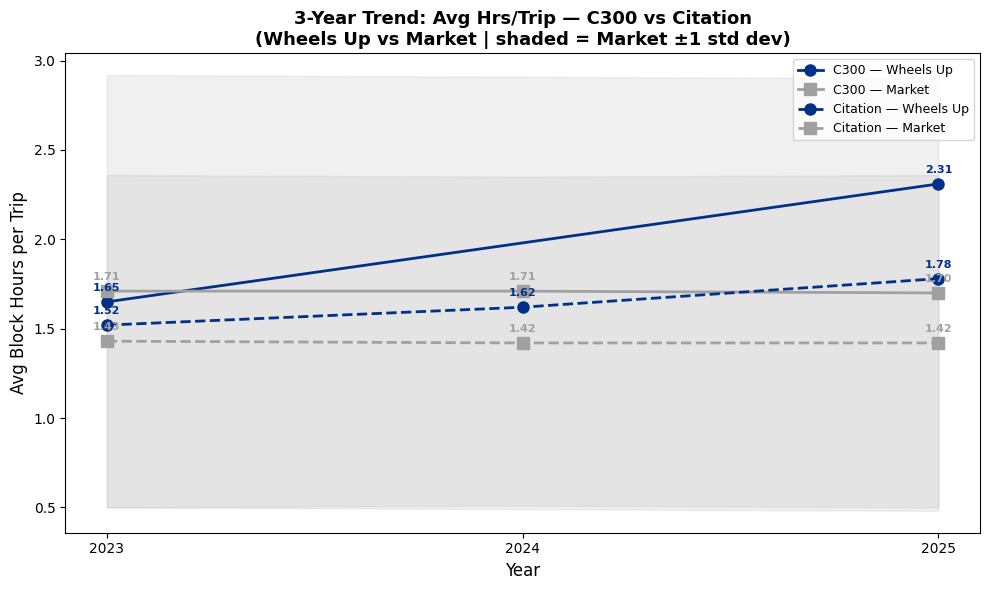

In [74]:
# 3-Year Trend Line Chart — 4 lines: C300-WU, C300-Market, Citation-WU, Citation-Market
fig, ax = plt.subplots(figsize=(10, 6))

styles = {
    ('C300',    'Wheels Up'): dict(color='#003087', linestyle='-',  marker='o', label='C300 — Wheels Up'),
    ('C300',    'Market'):    dict(color='#A0A0A0', linestyle='-',  marker='s', label='C300 — Market'),
    ('Citation','Wheels Up'): dict(color='#003087', linestyle='--', marker='o', label='Citation — Wheels Up'),
    ('Citation','Market'):    dict(color='#A0A0A0', linestyle='--', marker='s', label='Citation — Market'),
}

for (grp, op), style in styles.items():

    sub = stats_3yr[
        (stats_3yr['aircraft_group'] == grp) &
        (stats_3yr['operator_group'] == op)
    ].sort_values('year')

    if sub.empty:
        continue

    # plot line
    ax.plot(sub['year'], sub['Mean'], linewidth=2, markersize=8, **style)

    # SHADE ONLY MARKET STD DEV
    if op == "Market":
        ax.fill_between(
            sub['year'],
            sub['Mean'] - sub['Std'],
            sub['Mean'] + sub['Std'],
            color=style['color'],
            alpha=0.15
        )

    # annotate values
    for _, row in sub.iterrows():
        ax.annotate(
            f"{row['Mean']:.2f}",
            xy=(row['year'], row['Mean']),
            xytext=(0, 8),
            textcoords='offset points',
            ha='center',
            fontsize=8,
            color=style['color'],
            fontweight='bold'
        )

ax.set_xticks([2023, 2024, 2025])
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Avg Block Hours per Trip', fontsize=12)

ax.set_title(
    '3-Year Trend: Avg Hrs/Trip — C300 vs Citation\n'
    '(Wheels Up vs Market | shaded = Market ±1 std dev)',
    fontsize=13,
    fontweight='bold'
)

ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

In [75]:
# Top 5 models across C300 + Citation (3-year combined)
top5_models_3yr = df_3yr['aircraft_model'].value_counts().head(5).index.tolist()
df_3yr_top5 = df_3yr[df_3yr['aircraft_model'].isin(top5_models_3yr)]

model_order_3yr = (
    df_3yr_top5.groupby('aircraft_model')['Hours'].median()
    .sort_values().index.tolist()
)
print('Top 5 models (3-year):', top5_models_3yr)

Top 5 models (3-year): ['Citation Latitude', 'Challenger 350', 'Citation XLS', 'Challenger 300', 'Citation CJ3']


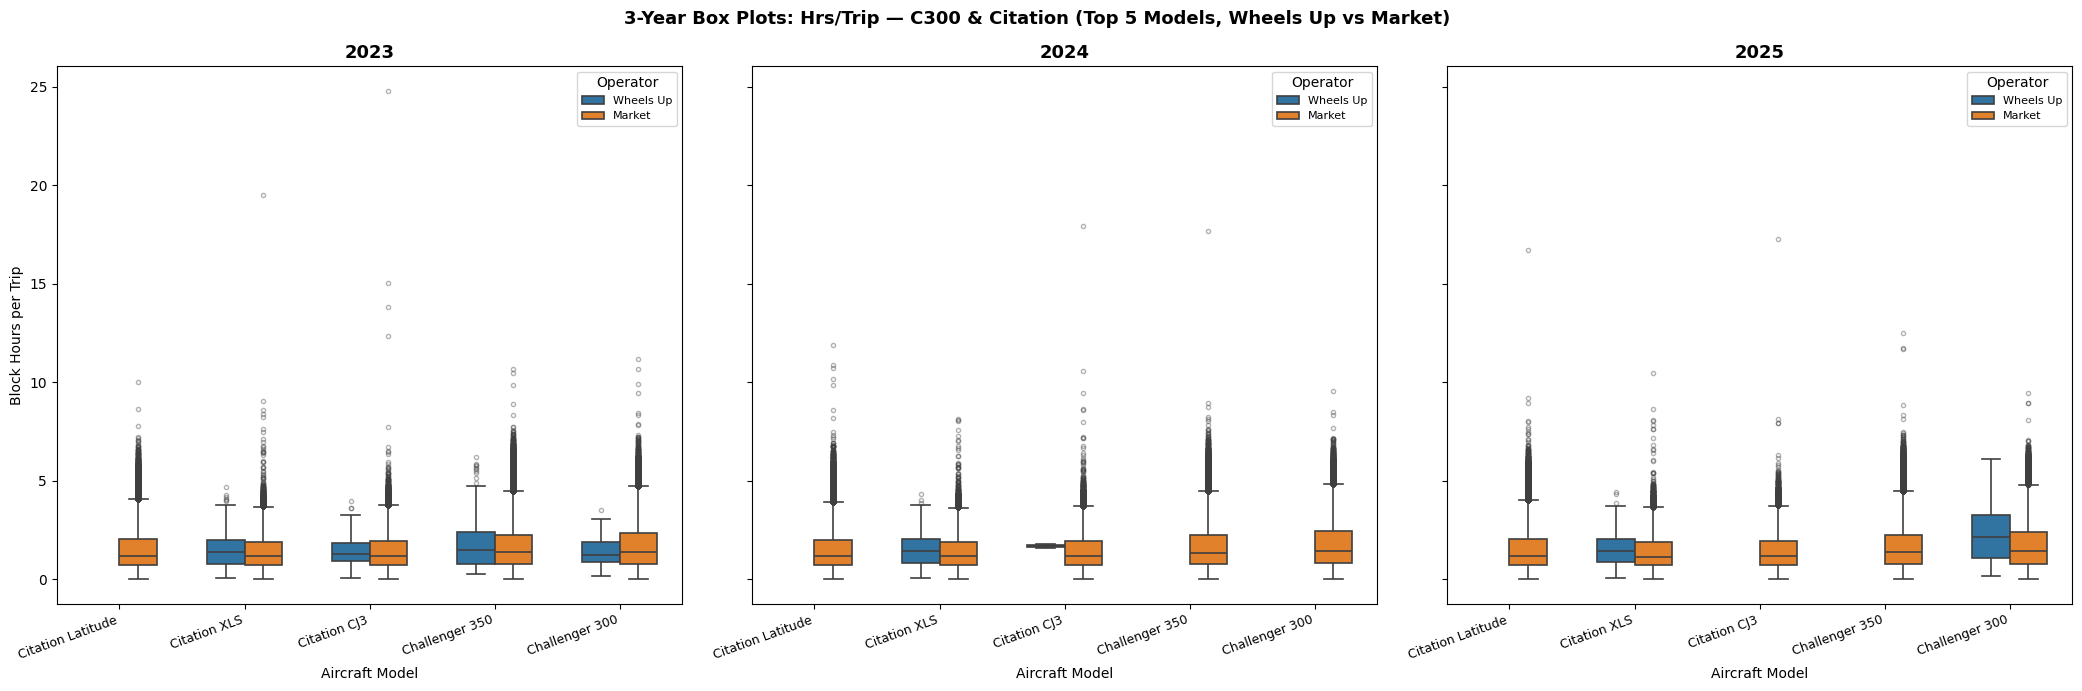

In [76]:
# 3-Year Box Plots — one subplot per year, WU vs Market
plt.close('all')
fig, axes = plt.subplots(1, 3, figsize=(21, 7), sharey=True)

for ax, yr in zip(axes, [2023, 2024, 2025]):
    yr_data = df_3yr_top5[df_3yr_top5['year'] == yr]

    sns.boxplot(
        data=yr_data,
        x='aircraft_model', y='Hours',
        hue='operator_group',
        order=model_order_3yr,
        hue_order=['Wheels Up', 'Market'],
        width=0.6, linewidth=1.2,
        flierprops=dict(marker='o', markersize=3, alpha=0.4),
        ax=ax
    )
    ax.set_title(str(yr), fontsize=13, fontweight='bold')
    ax.set_xlabel('Aircraft Model')
    ax.set_ylabel('Block Hours per Trip' if yr == 2023 else '')
    ax.legend(title='Operator', fontsize=8)
    plt.setp(ax.get_xticklabels(), rotation=20, ha='right', fontsize=9)

fig.suptitle('3-Year Box Plots: Hrs/Trip — C300 & Citation (Top 5 Models, Wheels Up vs Market)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [77]:
# Trend Summary — direction of change 2023 → 2025
print('=' * 70)
print('TREND SUMMARY: 2023 → 2025 Change in Avg Hrs/Trip')
print('=' * 70)

for grp in ['C300', 'Citation']:
    for op in ['Wheels Up', 'Market']:
        sub = stats_3yr[(stats_3yr['aircraft_group'] == grp) &
                        (stats_3yr['operator_group'] == op)].sort_values('year')
        if len(sub) < 2:
            continue

        start = sub.iloc[0]
        end   = sub.iloc[-1]
        delta = end['Mean'] - start['Mean']
        pct   = (delta / start['Mean']) * 100
        trend = 'UP ↑' if delta > 0.05 else ('DOWN ↓' if delta < -0.05 else 'STABLE →')
        std_chg = end['Std'] - start['Std']
        discipline = ('MORE disciplined (std ↓)' if std_chg < -0.05
                      else 'LESS disciplined (std ↑)' if std_chg > 0.05
                      else 'Consistent spread (std stable)')

        print(f'\n[{grp} — {op}]')
        print(f'  {int(start["year"])}: mean={start["Mean"]:.2f} hrs  std={start["Std"]:.2f}')
        print(f'  {int(end["year"])}: mean={end["Mean"]:.2f} hrs  std={end["Std"]:.2f}')
        print(f'  Change: {delta:+.2f} hrs ({pct:+.1f}%)  →  Trend: {trend}')
        print(f'  Discipline: {discipline}')

print('\n' + '=' * 70)

TREND SUMMARY: 2023 → 2025 Change in Avg Hrs/Trip

[C300 — Wheels Up]
  2023: mean=1.65 hrs  std=1.10
  2025: mean=2.31 hrs  std=1.40
  Change: +0.66 hrs (+40.0%)  →  Trend: UP ↑
  Discipline: LESS disciplined (std ↑)

[C300 — Market]
  2023: mean=1.71 hrs  std=1.21
  2025: mean=1.70 hrs  std=1.20
  Change: -0.01 hrs (-0.6%)  →  Trend: STABLE →
  Discipline: Consistent spread (std stable)

[Citation — Wheels Up]
  2023: mean=1.52 hrs  std=0.87
  2025: mean=1.78 hrs  std=1.09
  Change: +0.26 hrs (+17.1%)  →  Trend: UP ↑
  Discipline: LESS disciplined (std ↑)

[Citation — Market]
  2023: mean=1.43 hrs  std=0.93
  2025: mean=1.42 hrs  std=0.94
  Change: -0.01 hrs (-0.7%)  →  Trend: STABLE →
  Discipline: Consistent spread (std stable)



# new

In [84]:
corr = pd.read_csv(
    "gs://agntworks-data-dev/wheelsup/processed/wingx/wingx_cluster_monthly_2026.csv"
)

corr.head()

,cluster,month,inbound_hours,outbound_hours,total_hours,imbalance_ratio
0,ASPEN_CLUSTER,2026-01,2.020900e+05,1.980623e+05,4.001523e+05,0.010065
1,ASPEN_CLUSTER,2026-02,2.469929e+05,2.271396e+05,4.741325e+05,0.041873
2,ASPEN_CLUSTER,2026-03,2.423319e+05,2.860030e+05,5.283349e+05,-0.082658
3,ATLANTA_CLUSTER,2026-01,7.401775e+06,7.780166e+06,1.518194e+07,-0.024924
4,ATLANTA_CLUSTER,2026-02,8.230042e+06,8.715524e+06,1.694557e+07,-0.028650


In [85]:
corr['abs_imbalance'] = corr['imbalance_ratio'].abs()

top_clusters = corr.sort_values(
    'abs_imbalance',
    ascending=False
).head(10)

display(top_clusters[['cluster','month','imbalance_ratio']])

,cluster,month,imbalance_ratio
14,BRANSON_CLUSTER,2026-03,0.246043
13,BRANSON_CLUSTER,2026-02,0.189775
12,BRANSON_CLUSTER,2026-01,-0.182283
85,PUNTA_CANA_CLUSTER,2026-01,-0.167243
35,DUBAI_CLUSTER,2026-03,-0.154148
87,PUNTA_CANA_CLUSTER,2026-03,-0.150474
98,SAN_JUAN_CLUSTER,2026-02,-0.142122
67,NASSAU_CLUSTER,2026-01,-0.129240
109,VAIL_CLUSTER,2026-01,0.123268
97,SAN_JUAN_CLUSTER,2026-01,-0.117189


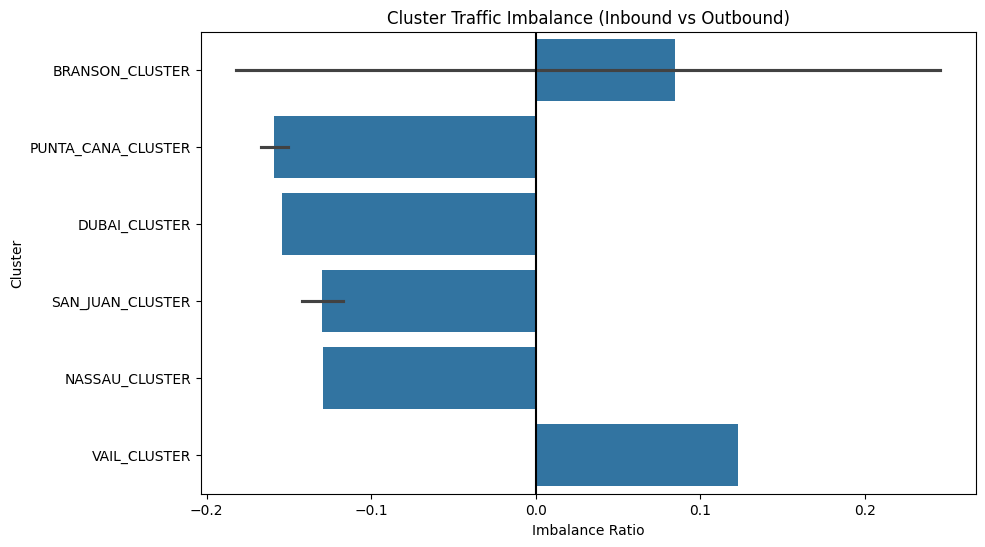

In [87]:
plt.figure(figsize=(10,6))

top = corr.loc[corr['imbalance_ratio'].abs().nlargest(10).index]

sns.barplot(
    data=top,
    x='imbalance_ratio',
    y='cluster'
)

plt.axvline(0,color='black')
plt.title("Cluster Traffic Imbalance (Inbound vs Outbound)")
plt.xlabel("Imbalance Ratio")
plt.ylabel("Cluster")

plt.show()

# Excluding Repositioning 

In [89]:
# Q1-2026 — C300 + P300, WU only, corridor-based
corr_q1_exp = pd.read_csv('gs://agntworks-data-dev/wheelsup/processed/wingx/wingx_corridor_2026.csv')

mask_c300_e = corr_q1_exp['aircraft_model'].str.contains('Challenger 300|Challenger 350|Challenger 3500', na=False)
mask_p300_e = corr_q1_exp['aircraft_model'].str.contains('Phenom 300', na=False)
corr_q1_exp = corr_q1_exp[mask_c300_e | mask_p300_e].copy()
corr_q1_exp['aircraft_group'] = np.where(mask_c300_e[corr_q1_exp.index], 'C300', 'P300')
corr_q1_exp = corr_q1_exp[corr_q1_exp['Operator'].str.contains('Wheels Up, na=False)].copy()

# Parse clusters from corridor string
corr_q1_exp[['from_cluster', 'to_cluster']] = corr_q1_exp['corridor'].str.split('→', expand=True)
corr_q1_exp['from_cluster'] = corr_q1_exp['from_cluster'].str.replace('_CLUSTER', '', regex=False).str.strip()
corr_q1_exp['to_cluster']   = corr_q1_exp['to_cluster'].str.replace('_CLUSTER', '', regex=False).str.strip()
corr_q1_exp['avg_hrs']      = corr_q1_exp['hours'] / corr_q1_exp['flights']

# Repositioning flags
is_same      = corr_q1_exp['from_cluster'] == corr_q1_exp['to_cluster']
is_repo_q1   = (is_same & (corr_q1_exp['from_cluster'] != 'OTHER') & (corr_q1_exp['avg_hrs'] <= 1.0)) | \
               (~is_same & (corr_q1_exp['avg_hrs'] <= 0.5))

print('Q1-2026 — Excluded as repositioning:')
display(corr_q1_exp[is_repo_q1].groupby('aircraft_group')[['flights','hours']].sum())
print('\nQ1-2026 — Kept as revenue flights:')
display(corr_q1_exp[~is_repo_q1].groupby('aircraft_group')[['flights','hours']].sum())

Q1-2026 — Excluded as repositioning:


,flights,hours
aircraft_group,,
C300,1,0.50
P300,1,0.35



Q1-2026 — Kept as revenue flights:


,flights,hours
aircraft_group,,
C300,573,1380.299167
P300,1610,2780.251667


In [92]:
is_same.isn

96        False
147       False
376       False
800       False
809       False
          ...  
178894    False
179146    False
179529    False
179774    False
180132    False
Length: 514, dtype: bool

In [90]:
# Before vs after comparison — Q1-2026
def weighted_avg(df):
    return (df['hours'].sum() / df['flights'].sum()).round(3)

before_q1 = corr_q1_exp.groupby('aircraft_group').apply(weighted_avg).rename('before')
after_q1  = corr_q1_exp[~is_repo_q1].groupby('aircraft_group').apply(weighted_avg).rename('after')

cmp_q1 = pd.concat([before_q1, after_q1], axis=1)
cmp_q1['delta']     = (cmp_q1['after'] - cmp_q1['before']).round(3)
cmp_q1['delta_pct'] = ((cmp_q1['delta'] / cmp_q1['before']) * 100).round(1).astype(str) + '%'

print('Q1-2026: Avg Hrs/Trip — Before vs After Repositioning Exclusion (WU)')
display(cmp_q1)

Q1-2026: Avg Hrs/Trip — Before vs After Repositioning Exclusion (WU)


,before,after,delta,delta_pct
aircraft_group,,,,
C300,2.406,2.409,0.003,0.1%
P300,1.726,1.727,0.001,0.1%
